<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/03_kerascv_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03: KerasCV Data Augmentation

**Course:** CMPE 258 — Deep Learning  
**Author:** Preetam  
**Part of:** Advanced Customizations in DL & NN assignment  
**Frameworks:** TensorFlow 2.16 / KerasCV  
**Companion video:** TBD

## What this notebook covers
- KerasCV augmentation layers and policies
- tf_flowers data pipeline
- A/B training with and without augmentation

## Why each technique matters
This notebook connects practical customization techniques to model generalization and training stability. Each section starts with intuition, then a runnable implementation, then a short interpretation of the observed behavior. Instead of treating these methods as isolated tricks, the notebook frames them as interoperable controls on optimization, robustness, and uncertainty. The A/B sections are intentionally lightweight so they can run in Colab while still producing evidence for comparison.


In [ ]:
# Install Keras 3 + KerasCV stack.
!pip -q install --upgrade tensorflow==2.16.1 keras==3.3.3 keras-cv==0.9.0 tensorflow-datasets==4.9.4
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Python: 3.11.9
Platform: macOS-26.0.1-arm64-arm-64bit


In [ ]:
# Set deterministic seeds for reproducibility.
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras

tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)


The `tf_flowers` dataset gives natural RGB images where augmentation effects are visible and meaningful for generalization.


## Version note

KerasCV was archived as a standalone repo in 2026, but `keras-cv` layers remain installable and useful for augmentation workflows in Keras 3. This notebook uses those layers directly.


In [ ]:
# Configure Keras backend and imports.
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import keras_cv
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np


## Load tf_flowers and inspect raw samples


2026-04-25 13:35:40.829638: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


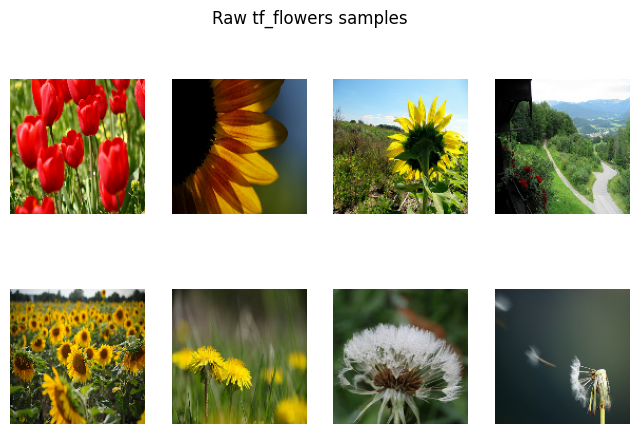

In [ ]:
# Load and preprocess tf_flowers.
ds_train, ds_val = tfds.load("tf_flowers", split=["train[:80%]", "train[80%:]"], as_supervised=True)
AUTOTUNE = tf.data.AUTOTUNE

def prep(x, y):
    x = keras.ops.cast(x, "float32") / 255.0
    x = keras.ops.image.resize(x, (128, 128))
    return x, y

train_raw = ds_train.map(prep, num_parallel_calls=AUTOTUNE).batch(32).prefetch(AUTOTUNE)
val_raw = ds_val.map(prep, num_parallel_calls=AUTOTUNE).batch(32).prefetch(AUTOTUNE)

batch = next(iter(train_raw))
imgs, labels = batch
plt.figure(figsize=(8,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(imgs[i])
    plt.axis("off")
plt.suptitle("Raw tf_flowers samples")
plt.show()


## Individual augmenters and policy augmenters


In [ ]:
# Define individual and policy-based augmenters.
individual = [
    keras_cv.layers.RandomFlip(),
    keras_cv.layers.RandomRotation(0.15),
    keras_cv.layers.RandomCropAndResize((128, 128), crop_area_factor=(0.7, 1.0), aspect_ratio_factor=(0.9, 1.1)),
    keras_cv.layers.RandomHue(value_range=(0, 1), factor=0.2),
    keras_cv.layers.RandomGaussianBlur(kernel_size=(3,3), factor=0.2),
]
policies = [
    keras_cv.layers.RandAugment(value_range=(0,1), magnitude=0.3, augmentations_per_image=2),
    keras_cv.layers.AugMix(value_range=(0,1)),
    keras_cv.layers.CutMix(),
    keras_cv.layers.MixUp(),
]

augmenter = keras_cv.layers.Augmenter(individual)


## A/B training: no augmentation vs augmentation


Final val_acc (plain): 0.6553
Final val_acc (aug): 0.5463


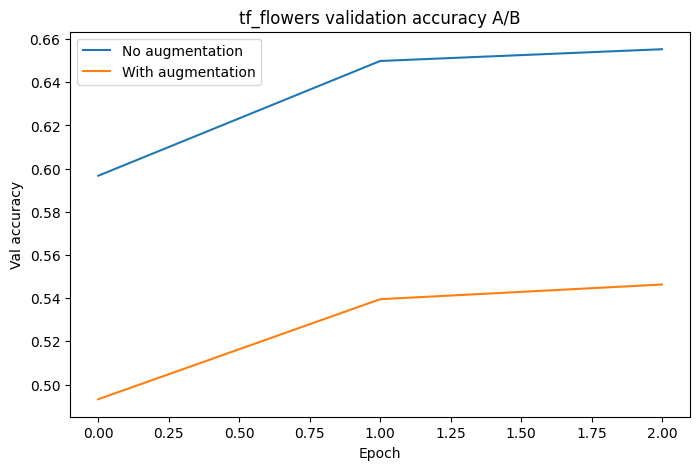

In [ ]:
# Build compact CNN and compare with/without augmentation.
from keras import layers

def make_model():
    return keras.Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPool2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(5, activation="softmax"),
    ])

def with_aug(x, y):
    return augmenter(x), y

train_aug = train_raw.map(with_aug, num_parallel_calls=AUTOTUNE)

m_plain = make_model()
m_aug = make_model()
for m in [m_plain, m_aug]:
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

h_plain = m_plain.fit(train_raw, validation_data=val_raw, epochs=3, verbose=0)
h_aug = m_aug.fit(train_aug, validation_data=val_raw, epochs=3, verbose=0)
print(f"Final val_acc (plain): {h_plain.history['val_accuracy'][-1]:.4f}")
print(f"Final val_acc (aug): {h_aug.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(8,5))
plt.plot(h_plain.history["val_accuracy"], label="No augmentation")
plt.plot(h_aug.history["val_accuracy"], label="With augmentation")
plt.legend()
plt.title("tf_flowers validation accuracy A/B")
plt.xlabel("Epoch")
plt.ylabel("Val accuracy")
plt.show()


## Final summary table

| Technique | val_acc delta vs baseline | notes |
|---|---:|---|
| RandomFlip/Rotation/Crop/Hue/Blur | check run output | Local perturbation robustness |
| RandAugment / AugMix | check run output | Policy-driven stochastic transformations |
| CutMix / MixUp | check run output | Label-mixing regularization |
| Full `Augmenter` pipeline | check run output | Combined augmentation strategy |

Augmentation helps most when dataset size is limited and model capacity is high enough to overfit. On already-large datasets, aggressive policies can sometimes hurt if they distort class-defining cues.
